<a href="https://colab.research.google.com/github/natalstein/Spectroelectrochemistry-fitting/blob/main/Uv_vis_gradient_dissent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from ipywidgets import interact


# Basic Equations



UV-Vis peaks are commonly modeled  Gaussian broadening:

$$ y = \frac{1}{\sigma\sqrt{2π}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

where sigma is standard diviation that determines the width of the peak, x is a wavelnegth and $\mu$ is the wavelength of maximum absorbance.

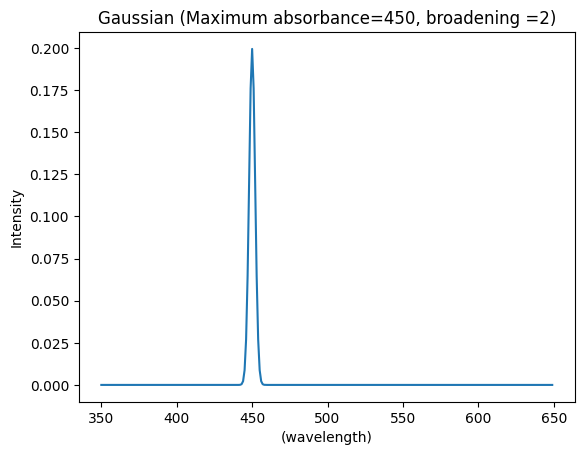

In [29]:

lam_max = 450
sigma = 2
lams = np.arange(350, 650, 1)

def gaussian(my_lam_max, my_sigma, my_lams):
    return (1/(my_sigma*np.sqrt(2*np.pi))) * np.exp(-(my_lams-my_lam_max)**2/(2*my_sigma**2))

def plot_gaussian(my_lam_max, my_sigma, my_lams):
    y = gaussian(my_lam_max, my_sigma, my_lams)

    plt.figure()
    plt.plot(my_lams, y)
    plt.title(f"Gaussian (Maximum absorbance={my_lam_max}, broadening ={my_sigma})")
    plt.xlabel("(wavelength)")
    plt.ylabel("Intensity")
    plt.show()

plot_gaussian(lam_max, sigma, lams)

# Simbolic math in Sympy

In [6]:
import sympy as sym

In [15]:
l_sym = sym.symbols('l_sym')
l_max_sym = sym.symbols('l_max_sym')
sigma_sym = sym.symbols('sigma_sym')

B = 1/(sigma_sym*sym.sqrt(sym.pi)*sym.sqrt(2))*sym.exp(-(l_sym-l_max_sym)**2/(2*sigma_sym**2))
sym.simplify(B)

sqrt(2)*exp(-(l_max_sym - l_sym)**2/(2*sigma_sym**2))/(2*sqrt(pi)*sigma_sym)

In [20]:
B_sigma_sym = sym.diff(B, sigma_sym)
B_l_max_sym = sym.diff(B, l_max_sym)
B_l_max_sym

-sqrt(2)*(2*l_max_sym - 2*l_sym)*exp(-(-l_max_sym + l_sym)**2/(2*sigma_sym**2))/(4*sqrt(pi)*sigma_sym**3)

# Torch

In [21]:
import torch

Step 0 | Loss 0.00053978 | sigma 3.049 | lam_max 430.100
Step 100 | Loss 0.00006894 | sigma 8.973 | lam_max 440.403
Step 200 | Loss 0.00000665 | sigma 10.205 | lam_max 446.907
Step 300 | Loss 0.00000035 | sigma 10.196 | lam_max 449.334
Step 400 | Loss 0.00000001 | sigma 10.091 | lam_max 449.910
Step 500 | Loss 0.00000000 | sigma 10.034 | lam_max 449.993
Step 600 | Loss 0.00000000 | sigma 10.011 | lam_max 450.000
Step 700 | Loss 0.00000000 | sigma 10.003 | lam_max 450.000
Step 800 | Loss 0.00000000 | sigma 10.001 | lam_max 450.000
Step 900 | Loss 0.00000000 | sigma 10.000 | lam_max 450.000


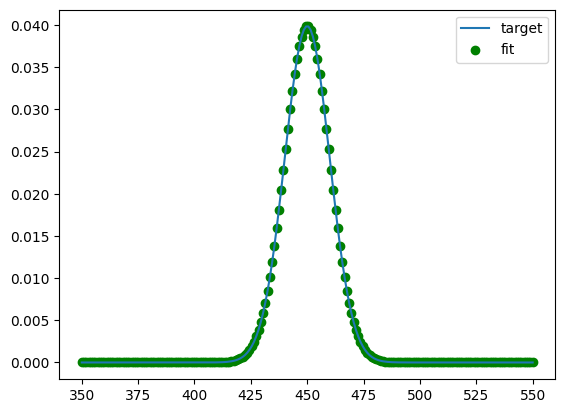

In [44]:


import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

lam = torch.linspace(350, 550, 200)

true_sigma = 10.0
true_lam_max = 450.0

target = (1/(true_sigma * torch.sqrt(torch.tensor(2*torch.pi)))) * \
         torch.exp(-(lam - true_lam_max)**2 / (2 * true_sigma**2))

# Better initialization
sigma_raw = torch.tensor(3.0, requires_grad=True)
lam_max = torch.tensor(430.0, requires_grad=True)

optimizer = torch.optim.Adam([sigma_raw, lam_max], lr=0.1)

for step in range(1000):
    optimizer.zero_grad()

    sigma = F.softplus(sigma_raw) + 1e-6

    pred = (1/(sigma * torch.sqrt(torch.tensor(2*torch.pi)))) * \
           torch.exp(-(lam - lam_max)**2 / (2 * sigma**2))

    loss = torch.mean((pred - target)**2)

    loss.backward()
    optimizer.step()

    if step % 100 == 0:
        print(
            f"Step {step} | Loss {loss.item():.8f} | "
            f"sigma {sigma.item():.3f} | lam_max {lam_max.item():.3f}"
        )

plt.plot(lam.numpy(), target.numpy(), label="target")
plt.scatter(lam.numpy(), pred.detach().numpy(), c = 'green', label="fit")
plt.legend()
plt.show()